In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Loading
df = pd.read_csv('data_incentive_attitudes.csv')

# Some basic data preprocessing steps
df = df.drop('Unnamed: 0', axis='columns')
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

# Replacing 'pub' with 'train' in `mode` column.
selected_mode = df['mode'].to_numpy()
df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)

df.head()

,user_id,trip_id,departure_time,arrival_time,Purpose,buscost,bustime,carcost,cartime,cardistance,...,SEX,AGE,INCOME,recco,information,incentivezone,value,task,job_type,income_con
0,20006,99545,10/28/2020 17:51,10/28/2020 19:21,101,770,69.4,151.7,43.72,15.17,...,1,36,4,2,only enviro,0,1,1,company employee,9000000
1,20006,100663,10/29/2020 17:58,10/29/2020 19:14,101,690,66.2,128.6,38.96,12.86,...,1,36,4,2,only enviro,0,1,2,company employee,9000000
2,20006,101712,10/30/2020 17:39,10/30/2020 19:05,101,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,3,company employee,9000000
3,20006,101878,10/30/2020 21:00,10/30/2020 21:25,998,500,56.2,118.5,29.53,11.85,...,1,36,4,1,no info,0,1,4,company employee,9000000
4,20006,100936,10/30/2020 7:14,10/30/2020 8:29,100,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,5,company employee,9000000


In [3]:
# What is `recco`?

In [4]:
basic_variables = list(df.columns)[:5]

purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

alternative_specific_variables = list(df.columns)[5:29]
alternative_specific_variables.remove('mode')

attitudinal_variables = list(df.columns)[29:-10]
generic_variables = ['SEX', 'AGE', 'INCOME', 'job_type', 'information']

# <ins><b>Data Preprocessing</b></ins>

## Feature Encoding

In [5]:
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

In [6]:
ohe = OneHotEncoder()

In [7]:
# utility functions for extracting time-zones and trip duration information from arrival and departure times of a trip.

def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 6:00) - 1
    AM peak (6:00 to 10:00) - 2
    Off peak (10:00 to 16:00) - 3
    PM peak (16:00 to 20:00) - 4
    Evening (20:00 to 00:00) - 5
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 6:
        return 1
    elif dep_hrs >= 6 and dep_hrs < 10:
        return 2
    elif dep_hrs >= 10 and dep_hrs < 16:
        return 3
    elif dep_hrs >= 16 and dep_hrs < 20:
        return 4
    else:
        return 5

In [8]:
# `job_type` column
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]
job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)
job_type_df = job_type_df.drop(job_type_df.columns[0], axis=1)

# `information` column
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])
info_df = info_df.drop(info_df.columns[0], axis=1)

# `SEX` column
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])
SEX_df = SEX_df.drop(SEX_df.columns[0], axis=1)

# `Purpose` column
Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)
Purpose_df = Purpose_df.drop(Purpose_df.columns[0], axis=1)

# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in time zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['Early_morning_departure', 'AM_peak_departure', 'Off_peak_departure', 'PM_peak_departure', 'Night_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)

In [9]:
# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')

# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'value', 'task', 'income_con'], axis='columns')

df2.head()

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,walkcost,biketime,...,job_type_Part time job,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,no info,only enviro,only health
0,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,690,66.2,128.6,38.96,12.86,240,44.9,154.32,0,51.44,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,500,56.2,118.5,29.53,11.85,400,59.0,142.20,0,47.40,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


<AxesSubplot:>

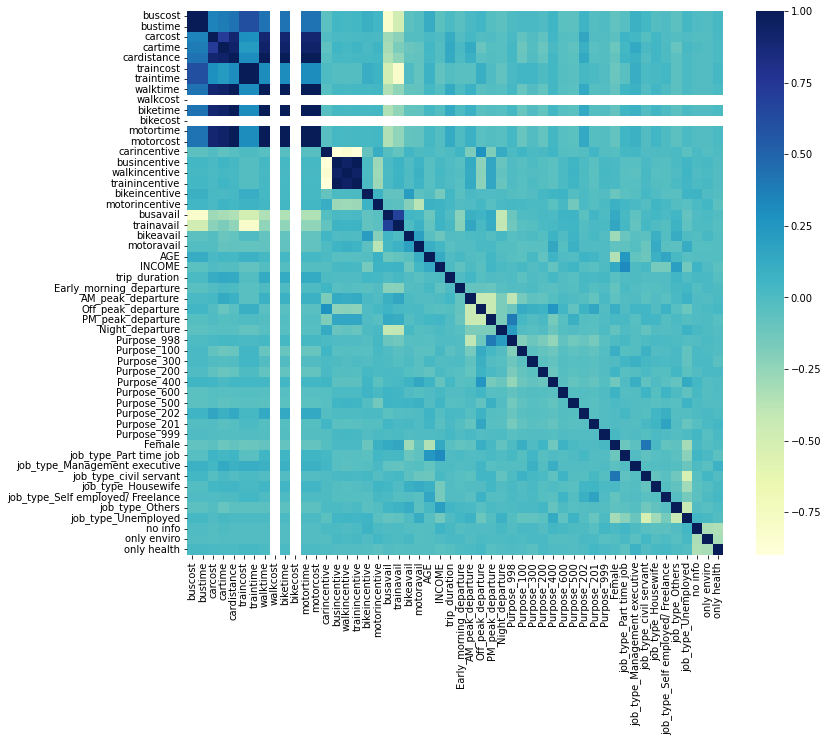

In [10]:
# all the alternative specific variables are heavily correlated with each other

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.heatmap(df2.drop(attitudinal_variables, axis='columns').corr(numeric_only=True), cmap='YlGnBu', annot=False, ax=ax)

## <b>Additional Feature Processing Steps</b>

In [11]:
# Creating travelcost, traveltime, travelincentive
df3 = df2.copy()
df3['travelcost'] = df3.T.apply(lambda x: x['{mode}cost'.format(mode=x['mode'])])
df3['traveltime'] = df3.T.apply(lambda x: x['{mode}time'.format(mode=x['mode'])])
df3['travelincentive'] = df3.T.apply(lambda x: x['{mode}incentive'.format(mode=x['mode'])])

unique_modes = ['train', 'bus', 'car', 'walk', 'bike', 'motor']
cost_cols = [f'{mode}cost' for mode in unique_modes]
time_cols = [f'{mode}time' for mode in unique_modes]
incen_cols = [f'{mode}incentive' for mode in unique_modes]

df3 = df3.drop(cost_cols+time_cols+incen_cols + ['cardistance', 'trip_duration'], axis='columns')

## Dealing with outliers

In [12]:
df4 = df2.copy()

In [13]:
def winsorize_single_variable(df, var_name, delta=2):
    # Quantile based winsorization on trip duration
    Q1 = df[var_name].quantile(0.25)
    Q3 = df[var_name].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + delta*IQR
    var = df[var_name].to_numpy()
    var = np.where((var <= upper_bound), var, upper_bound)

    df[var_name] = var
    return df

In [14]:
def winsorize_multiple_variables(df, var_name_list, delta=1.9):
    for i in range(len(var_name_list)):
        Q1 = df[var_name_list[i]].quantile(0.25)
        Q3 = df[var_name_list[i]].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + delta * IQR
        lower_bound = Q1 - delta * IQR
        var_arr = df[var_name_list[i]].to_numpy()
        df[var_name_list[i]] = np.where((var_arr <= upper_bound) & (var_arr >= lower_bound), var_arr, upper_bound)
    return df

In [15]:
df4 = winsorize_single_variable(df4, 'trip_duration')
df4 = winsorize_multiple_variables(df4, list(alternative_specific_variables[:-4]))

## Train and Test Split

In [16]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.preprocessing import StandardScaler

In [73]:
def get_train_test_data(df, drop_att_vars=True, apply_smote=False, apply_tomek_links=False, 
                        apply_standardization=False, cols_to_standardize=[]):
    if drop_att_vars:
        df = df.drop(attitudinal_variables, axis='columns')
    
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=500)
    
    label_mapping_dict = {'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}
    
    y_train = np.array([label_mapping_dict[label] for label in train_df['mode']])
    X_train = train_df.drop('mode', axis='columns')
    y_test = np.array([label_mapping_dict[label] for label in test_df['mode']])
    X_test = test_df.drop('mode', axis='columns')
    
    if apply_smote:
        smote = SMOTE(random_state=500)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        X_test, y_test = smote.resample(X_test, y_test)
    
    if apply_tomek_links:
        tomek = TomekLinks()
        X_train, y_train = tomek.fit_resample(X_train, y_train)
        X_test, y_test = tomek.resample(X_test, y_test)
    
    if apply_standardization:
        ss =  StandardScaler()
        X_train_scaled_arr = ss.fit_transform(X_train[cols_to_standardize])
        X_test_scaled_arr = ss.transform(X_test[cols_to_standardize])
        X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=cols_to_standardize)
        X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=cols_to_standardize)
        X_train_scaled.set_index(X_train.index, inplace=True)
        X_test_scaled.set_index(X_test.index, inplace=True)
        X_train.iloc[0:X_train.shape[0], X_train.columns.get_indexer(cols_to_standardize)] = X_train_scaled
        X_test.iloc[0:X_test.shape[0], X_test.columns.get_indexer(cols_to_standardize)] = X_test_scaled
        
    return ((X_train, y_train), (X_test, y_test)), label_mapping_dict

In [163]:
output_categories = ['bus', 'car', 'train', 'walk', 'bike', 'motor']

asc_variable_names = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walkcost', 'walktime', 'walkincentive'],
    'bike': [ 'bikecost', 'biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

avail_variable_names = {
    'bus': 'busavail',
    'train': 'trainavail',
    'bike': 'bikeavail',
    'motor': 'motoravail'
}

In [164]:
cols_to_standardize = ['AGE']
for category in output_categories:
    cols_to_standardize.extend(asc_variable_names[category])

In [165]:
((X_train, y_train), (X_test, y_test)), label_mapping_dict = get_train_test_data(df4, drop_att_vars=True, 
                                                                apply_standardization=True, 
                                                                cols_to_standardize=cols_to_standardize)
label_mapping_dict

{'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}

In [166]:
def get_generic_vars_names(asc_variable_names, avail_variable_names):
    asc_variables_list = []
    for category_asc_variables in asc_variable_names.values():
        asc_variables_list.extend(category_asc_variables)
    return list(X_train.drop(asc_variables_list, axis=1, errors='ignore').drop(
        avail_variable_names.values(), axis=1, errors='ignore').columns)

In [167]:
generic_variable_names = get_generic_vars_names(asc_variable_names, avail_variable_names)
for item in ['cardistance', 'trip_duration']:
    if item in generic_variable_names:
        generic_variable_names.remove(item)

asc_variable_indexer = dict()
for category in output_categories:
    asc_variable_indexer[category] = X_train.columns.get_indexer(asc_variable_names[category])

avail_variable_indexer = dict(zip(avail_variable_names.keys(), 
                                  X_train.columns.get_indexer(avail_variable_names.values())))

generic_variable_indexer = dict(zip(generic_variable_names, 
                                  X_train.columns.get_indexer(generic_variable_names)))

In [170]:
generic_variable_names

['AGE',
 'INCOME',
 'Early_morning_departure',
 'AM_peak_departure',
 'Off_peak_departure',
 'PM_peak_departure',
 'Night_departure',
 'Purpose_998',
 'Purpose_100',
 'Purpose_300',
 'Purpose_200',
 'Purpose_400',
 'Purpose_600',
 'Purpose_500',
 'Purpose_202',
 'Purpose_201',
 'Purpose_999',
 'Female',
 'job_type_Part time job',
 'job_type_Management executive',
 'job_type_civil servant',
 'job_type_Housewife',
 'job_type_Self employed/ Freelance',
 'job_type_Others',
 'job_type_Unemployed',
 'no info',
 'only enviro',
 'only health']

# <ins><b>Model Formulation</b></ins>

In [156]:
import tensorflow as tf

In [171]:
def replace_nan_with_zeros(tensor):
    nan_mask = tf.math.is_nan(tensor)
    zeros_mask = tf.zeros_like(tensor)
    replaced_tensor = tf.where(nan_mask, zeros_mask, tensor)
    return replaced_tensor


class SparseCategoricalCrossEntropy(tf.keras.losses.Loss):
    
    def __init__(self, from_logits=True, reduction=tf.keras.losses.Reduction.AUTO, name='sparse_categorical_crossentropy'):
        super(SparseCategoricalCrossEntropy, self).__init__(reduction=reduction, name=name)
        self.from_logits = from_logits
        
    def call(self, true_y, pred_y):
        if self.from_logits:
            pred_y = tf.nn.softmax(pred_y, axis=-1)
        
        batch_avail_data = self.avail_data
        true_y = tf.cast(true_y, dtype='int32')
        
        # Masking the original softmax probabilities based on availability data
        # and normalizing the masked probabilities to effectively negate the effect 
        # of non-available label class data.
        masked_probs = pred_y * tf.cast(batch_avail_data, dtype=pred_y.dtype)
        summed_probs = tf.reduce_sum(masked_probs, axis=-1, keepdims=True)
        pred_y = masked_probs / (summed_probs + tf.keras.backend.epsilon())      
        
        # one hot encoding the true_y to match the shape of tf.math.log() which has shape (n, 6)
        depth = 6
        ohe_true_y = tf.one_hot(true_y, depth, on_value=1, off_value=0, axis=-1, dtype=pred_y.dtype)
        loss_with_nan = ohe_true_y * tf.math.log(pred_y + tf.keras.backend.epsilon())
        loss = -tf.reduce_mean(replace_nan_with_zeros(loss_with_nan))
        return loss
    
    def set_avail_data(self, X, output_categories, avail_variable_indexer):
        X = tf.cast(X, dtype='float32')
        avail_data = []
        for category in output_categories:
            if category in avail_variable_indexer:
                avail_data.append(tf.gather(X, avail_variable_indexer[category], axis=1))
            else:
                avail_data.append(tf.ones(X.shape[0],))
        self.avail_data = tf.transpose(avail_data)

In [172]:
class EvaluationMetrics(object):
    def __init__(self, metrics_dict=None):
        if metrics_dict is None:
            metrics_dict = {'Loss':[], 'Accuracy':[], 'Precision':[], 'Recall':[], 'F1Score':[]}
        self.metrics_dict = metrics_dict
        self.batch_metrics_dict = None
        
    def precision(self, y_true, y_pred, average='macro'):
        num_classes = tf.reduce_max(y_true)

        precision_values = tf.TensorArray(tf.float32, size=num_classes, dynamic_size=False)

        for class_label in range(1, num_classes + 1):
            true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))
            false_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))

            precision_value = true_positives / (true_positives + false_positives + 1e-7)
            precision_values = precision_values.write(class_label - 1, precision_value)

        precision_values = precision_values.stack()

        if average == 'macro':
            precision_mean = tf.reduce_mean(precision_values)
            return precision_mean
        elif average == 'micro':
            true_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, y_pred), tf.not_equal(y_pred, -1)), tf.float32))
            false_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, y_pred), tf.equal(y_pred, -1)), tf.float32))
            precision_micro = true_positives_total / (true_positives_total + false_positives_total + 1e-7)
            return precision_micro
        else:
            return precision_values
    
    
    def recall(self, y_true, y_pred, average='macro'):
        num_classes = tf.reduce_max(y_true)

        recall_values = tf.TensorArray(tf.float32, size=num_classes, dynamic_size=False)

        for class_label in range(1, num_classes+1):
            true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))
            false_negatives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.not_equal(y_pred, class_label)), tf.float32))

            recall_value = true_positives / (true_positives + false_negatives + 1e-7)
            recall_values = recall_values.write(class_label - 1, recall_value)
        
        recall_values = recall_values.stack()
        
        if average == 'macro':
            recall_mean = tf.reduce_mean(recall_values)
            return recall_mean
        elif average == 'micro':
            true_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, y_pred), tf.not_equal(y_pred, -1)), tf.float32))
            false_negatives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, y_pred), tf.equal(y_pred, -1)), tf.float32))
            recall_micro = true_positives_total / (true_positives_total + false_negatives_total + 1e-7)
            return recall_micro
        
        return recall_values
    
    
    def f1_score(self, y_true, y_pred, average='macro'):
        precisions = self.precision(y_true, y_pred, average=average)
        recalls = self.recall(y_true, y_pred, average=average)

        f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-7)
        
        return f1_scores
    
    
    def accuracy(self, y_true, y_pred):
        correct_predictions = tf.cast(tf.equal(y_true, y_pred), dtype=tf.float32)
        accuracy = tf.reduce_mean(correct_predictions)
        
        return accuracy
    
    
    def update_epoch_metrics(self, print_results=False):
        if self.batch_metrics_dict is not None:
            epoch_loss = tf.reduce_mean(self.batch_metrics_dict['Loss'])
            epoch_accuracy = tf.reduce_mean(self.batch_metrics_dict['Accuracy'])
            epoch_precision = tf.reduce_mean(self.batch_metrics_dict['Precision'])
            epoch_recall = tf.reduce_mean(self.batch_metrics_dict['Recall'])
            epoch_f1score = tf.reduce_mean(self.batch_metrics_dict['F1Score'])
        else:
            raise Exception('Batch metrics are not calculated yet.')
            
        self.metrics_dict['Loss'].append(epoch_loss)
        self.metrics_dict['Accuracy'].append(epoch_accuracy)
        self.metrics_dict['Precision'].append(epoch_precision)
        self.metrics_dict['Recall'].append(epoch_recall)
        self.metrics_dict['F1Score'].append(epoch_f1score)
        
        
        if print_results:
            print("---------------------------------------")
            print(f'Mean -ve log-likelihood: {epoch_loss:.3f}')
            print(f'Accuracy: {epoch_accuracy:.3f}')
            print(f'Precision: {epoch_precision:.3f}')
            print(f'Recall: {epoch_recall:.3f}')
            print(f'F1-Score: {epoch_f1score:.3f}')
            print("---------------------------------------")

        
        self.batch_metrics_dict = None

    
    def update_batch_metrics(self, y_true, y_pred, loss, average='macro', batch_metrics_dict=None):
        
        if self.batch_metrics_dict is None:
            self.batch_metrics_dict = {'Loss':[], 'Precision':[], 'Accuracy':[], 'Recall':[], 'F1Score':[]}
        
        if len(y_pred.shape) != 1:
            y_pred = tf.argmax(y_pred, axis=-1)
        
        y_true = tf.cast(y_true, dtype='int32')
        y_pred = tf.cast(y_pred, dtype='int32')
        
        curr_precision = self.precision(y_true, y_pred, average=average)
        self.batch_metrics_dict['Precision'].append(curr_precision)
        
        curr_recall = self.recall(y_true, y_pred, average=average)
        self.batch_metrics_dict['Recall'].append(curr_recall)
        
        curr_f1_score = self.f1_score(y_true, y_pred, average=average)
        self.batch_metrics_dict['F1Score'].append(curr_f1_score)
        
        curr_accuracy = self.accuracy(y_true, y_pred)
        self.batch_metrics_dict['Accuracy'].append(curr_accuracy)
        
        self.batch_metrics_dict['Loss'].append(loss)
    
    
    def metrics_variation_plots(self):
        fig, ax = plt.subplots(2, 2, figsize=(15, 10))
        
        ax[0, 0].plot(np.arange(len(self.metrics_dict['Loss'])), self.metrics_dict['Loss'], marker='o', lw=1, c='blue')
        ax[0, 0].set_ylabel('Mean negative log-likelihood (MNLL)')
        
        ax[0, 1].plot(np.arange(len(self.metrics_dict['Accuracy'])), self.metrics_dict['Accuracy'], marker='o', lw=1, c='orange')
        ax[0, 1].set_ylabel('Accuracy')
        
        ax[1, 0].plot(np.arange(len(self.metrics_dict['Precision'])), self.metrics_dict['Precision'], marker='o', lw=1, c='red')
        ax[1, 0].set_ylabel('Precision')
        
        ax[1, 1].plot(np.arange(len(self.metrics_dict['Recall'])), self.metrics_dict['Recall'], marker='o', lw=1, c='green')
        ax[1, 1].set_ylabel('Recall')
        
    
    def reset_states(self):
        for metric, _ in self.metrics_dict.items():
            self.metrics_dict[metric] = []


In [232]:
class AltSpecDense(tf.keras.layers.Layer):
    def __init__(self, asc_variables):
        """
        `asc_variables`: A dictionary like object with keys as unique predicting labels and values as the list of 
                         corresponding alternative specific variables for that particular predicting label.
        """
        super(AltSpecDense, self).__init__()
        self.units = len(asc_variables)
        self.categories = list(asc_variable_indexer.keys())
        self.asc_variables = asc_variables
    
    def set_reference_category(self, reference_category):
        self.reference_category = reference_category
        
    def build(self, input_shape):
        
        if self.reference_category is None:
            raise Exception("First set the reference category")
        
        w_init = tf.random_normal_initializer()
        b_init = tf.zeros_initializer()
        
        self.w = []
        bias = []
        n = len(self.asc_variables[self.categories[0]])
        travel_weights = tf.Variable(initial_value=w_init(shape=(n, 1), dtype='float32'),
                                    trainable=True, name=f'travel_weights')
        for category in self.categories:
            n = len(self.asc_variables[category])
            if category != self.reference_category:
                self.w.append(travel_weights)
                bias.append(tf.Variable(
                                initial_value = b_init(shape=(1,), 
                                                       dtype='float32'),
                                trainable=True, name='non_refernce_bias'))
                
            else:
                self.w.append(tf.Variable(
                                initial_value=tf.zeros(shape=(n, 1),
                                                      dtype='float32'),
                                trainable=False, name=f'{category}_weights'))
                bias.append(tf.Variable(
                                initial_value = b_init(shape=(1,), dtype = 'float32'),
                                trainable = False, name = 'refernce_bias'))
                
        self.b = bias
    
    def call(self, inputs):
        # Calulating the utility of each category (predicting class) without the asc constant (bias)
        total_alt_spec_utility = []
        for i, category in enumerate(self.categories):
            category_asc_vars = tf.gather(inputs, self.asc_variables[category], axis=1)
            category_asc_utility = tf.matmul(category_asc_vars, self.w[i])
            total_alt_spec_utility.append(category_asc_utility)
        total_alt_spec_utility = tf.concat(total_alt_spec_utility, axis=1)
        return total_alt_spec_utility + tf.transpose(self.b)

In [690]:
class MNLModel(tf.keras.models.Model):
    def __init__(self, generic_vars_indices, asc_variables=asc_variable_indexer, 
                 output_categories=output_categories, avail_variables=avail_variable_indexer, reference_category='car'):
        """
            `generic_vars_indices`: List or similar object containing indices of generic variables.
             asc_variables`: A dictionary like object with keys as unique predicting labels and values as the list of 
                         corresponding alternative specific variables for that particular predicting label.
                         Defaults to all the present asc variables indexer dictionary.
        """
        super(MNLModel, self).__init__()
        self.generic_utility_layer = tf.keras.layers.Dense(1, use_bias=False) # use 6 for different betas for each class and 1 for the same betas for each class
        self.alt_spec_utility_layer = AltSpecDense(asc_variables=asc_variables)
        self.generic_vars_indices = generic_vars_indices
        self.output_categories = output_categories
        self.avail_variables = avail_variables
        self.asc_variables = asc_variables
        self.in_graph_execution = False
        self.reference_category = reference_category
    
    
    def call(self, x):
        #generic_x = tf.gather(x, self.generic_vars_indices, axis=1)
        
        #generic_utility_1 = self.generic_utility_layer(generic_x)
        #generic_utility = tf.repeat(generic_utility_1, repeats=6, axis=1)
        self.alt_spec_utility_layer.set_reference_category(self.reference_category)
        alt_spec_utility = self.alt_spec_utility_layer(x)
        
        #total_utility = alt_spec_utility + generic_utility
        
        # Using 'car' as the reference class, (i.e.) assuming its utility to be 0 and calculating all utilities w.r.t this class.
        #reference_category_index = self.output_categories.index('car')
        #absolute_reference_category_utility = total_utility[:, 1]
        #relative_utility = total_utility - tf.reshape(absolute_reference_category_utility, [-1, 1])
        
        #category_utlity_std = tf.math.reduce_std(relative_utility, axis=1, keepdims=True)
        #normalized_utility = relative_utility/category_utlity_std
        
        return alt_spec_utility
    
    
    def _generate_batches(self, X, y):
        n = X.shape[0]
        batches = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(n).batch(self.batch_size)
        return batches
    
    
    def _train_step(self, X, y):
        with tf.GradientTape() as tape:
            predictions = self.call(X)
            curr_loss = self.loss_object(y, predictions)
        gradients = tape.gradient(curr_loss, self.trainable_variables)
        self.optimizer_object.apply_gradients(zip(gradients, self.trainable_variables))
        
    
    def _test_step(self, X, y):
        predicitions = self.call(X)
        curr_loss = self.loss_object(y, predicitions)
    
    
    def train_and_test(self, train_X, train_y, test_X, test_y, batch_size=2, learning_rate=0.001, epochs=5, debug=False, metrics_average='macro'):
        
        # If not in debug mode, then training will happen in the most optimal graph execution mode, 
        # else it will occur in slower but better interpretable eager execution mode.
        if not debug and not self.in_graph_execution:
            self.in_graph_execution = True
            tf.function(self.train_and_test(train_X, train_y, test_X, test_y, batch_size=batch_size, 
                                            learning_rate=learning_rate, epochs=epochs, debug=debug, 
                                            metrics_average=metrics_average), reduce_retracing=True)
            return
        
        train_X = tf.convert_to_tensor(train_X, dtype='float32')
        train_y = tf.convert_to_tensor(train_y, dtype='float32')
        test_X = tf.convert_to_tensor(test_X, dtype='float32')
        test_y = tf.convert_to_tensor(test_y, dtype='float32')
        
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.metrics_average = metrics_average
        
        tf.random.set_seed(0)
        
        train_batches = self._generate_batches(train_X, train_y)
        test_batches = self._generate_batches(test_X, test_y)
        
        self.loss_object = SparseCategoricalCrossEntropy(from_logits=True)
        self.optimizer_object = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        
        self.train_metrics_object = EvaluationMetrics()
        self.test_metrics_object = EvaluationMetrics()
        
        for epoch in range(self.epochs):
            for x_train_batch, y_train_batch in train_batches:
                self.loss_object.set_avail_data(x_train_batch, self.output_categories, self.avail_variables)
                self._train_step(x_train_batch, y_train_batch)
            
            self.loss_object.set_avail_data(train_X, self.output_categories, self.avail_variables)
            train_preds =  self.call(train_X)
            train_loss =  self.loss_object(train_y, train_preds)
            self.train_metrics_object.update_batch_metrics(train_y, train_preds,  train_loss, average=self.metrics_average)
                
            for x_test_batch, y_test_batch in test_batches:
                self.loss_object.set_avail_data(x_test_batch, self.output_categories, self.avail_variables)
                self._test_step(x_test_batch, y_test_batch)
            
            self.loss_object.set_avail_data(test_X, self.output_categories, self.avail_variables)
            test_preds = self.call(test_X)
            test_loss = self.loss_object(test_y, test_preds)
            self.test_metrics_object.update_batch_metrics(test_y, test_preds, test_loss, average=self.metrics_average)

            
            if debug:
                print("Epoch:",epoch)
                print("Training Metrics:")
            self.train_metrics_object.update_epoch_metrics(print_results=debug)
            if debug:
                print("Testing Metrics:")
            self.test_metrics_object.update_epoch_metrics(print_results=debug)
            if debug:
                print("*************************************")
                print("*************************************")
    
    
    def plot_training_results(self):
        self.train_metrics_object.metrics_variation_plots()
    
    def plot_testing_results(self):
        self.test_metrics_object.metrics_variation_plots()
        
    def get_model_parameters(self, asc_variable_names_dict=asc_variable_names, 
                             generic_variable_names=generic_variable_names):
        
        bias_counter = 0
        oc = self.output_categories[:]
        oc.remove(self.reference_category)
        print(oc)
        
        for train_vars in self.trainable_variables:
            
            if train_vars.name.split('/')[-1].strip(':0') == 'kernel':
                generic_params = zip(generic_variable_names, train_vars.numpy())
                print(f"Parameters of generic variables:")
                for var_name, var_value in generic_params:
                    print(f"{var_name}: {var_value[0]:.3f}")
                print("*************************************************************")
            
            elif train_vars.name.split('/')[-1].strip(':0') == f"travel_weights":
                gen_params = zip(['travelcost', 'traveltime', 'travelincentive'], train_vars.numpy().flatten())
                print(f"Parameters of generic travel parameters:")
                for var_name, var_value in gen_params:
                    print(f"{var_name}: {var_value:.3f}")
                print("*************************************************************")
                
            else:
                print(f"{oc[bias_counter]}_constant: {train_vars.numpy().flatten()[0]:.3f}")
                bias_counter+=1
                print("*************************************************************")
    
    def get_class_utility(self, class_label, X_train):
        class_index=self.output_categories.index(class_label)
        utilities = self.call(X_train)
        return utilities
    
    def generate_hessian_matrix(self, X, y):
        travel_weights_list = ['travelcost', 'traveltime', 'travelincentive']
        X = tf.convert_to_tensor(X, dtype='float32')
        y = tf.convert_to_tensor(y, dtype='float32')
        self.loss_object.set_avail_data(X, self.output_categories, self.avail_variables)
        var_names = []
        with tf.GradientTape(persistent=True) as tape2:
            with tf.GradientTape(persistent=True) as tape:
                predictions = self.call(X)
                loss = self.loss_object(y, predictions)
            LL_grads = tape.gradient(loss, self.trainable_variables)
        hessians = []
        for grad_i in LL_grads:
            hess_i = tape2.jacobian(grad_i, self.trainable_variables)
            print(grad_i.numpy())
            hess_flat = []
            for hess_ii in hess_i:
                hess_ii_flat = hess_ii.numpy().flatten()
                if hess_ii_flat.ndim == 1:
                    hess_flat.extend(hess_ii_flat)
                else:
                    vals = hess_ii.numpy()
                    hess_ii_flat = np.hstack((np.squeeze(np.hstack(vals[:-1])), np.squeeze(vals[-1]).T))
                    hess_flat.extend(hess_ii_flat)
            print(hess_flat)
            hessians = np.concatenate((hessians, [[0, 1, 2, 4]]), axis=1)
            print("************************")
        print(hessians)
            
        
        
        

In [691]:
mnl_model.trainable_variables[-1][0]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.69263154], dtype=float32)>

In [692]:
mnl_model = MNLModel(list(generic_variable_indexer.values()), reference_category='bus')

In [693]:
BATCH_SIZE = 100
LEARNING_RATE = 1
EPOCHS = 1
METRICS_AVERAGE = 'macro'

mnl_model.train_and_test(X_train.to_numpy(), y_train, X_test.to_numpy(), y_test, 
                         debug=False, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, epochs=EPOCHS, 
                         metrics_average=METRICS_AVERAGE)

In [694]:
mnl_model.generate_hessian_matrix(X_train.to_numpy(), y_train)

[0.00179291]
[0.008643339, -0.006218366, -0.0019075836, -0.00041313726, -6.2347e-05, 0.0056329067, 0.004007596, 0.007320003]


AxisError: axis 1 is out of bounds for array of dimension 1

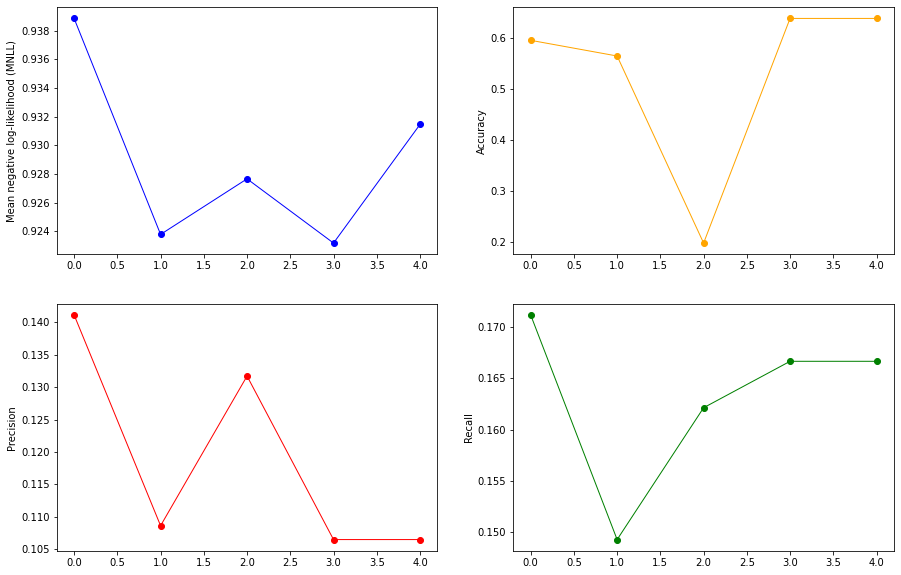

In [336]:
mnl_model.plot_training_results()

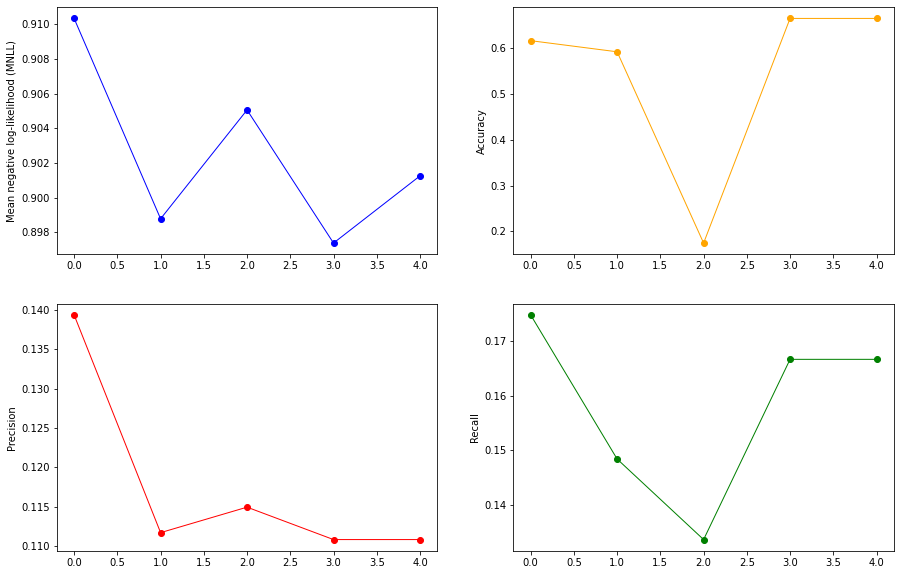

In [337]:
mnl_model.plot_testing_results()

In [338]:
mnl_model.get_model_parameters()

['bus', 'car', 'train', 'bike', 'motor']
bus_constant: -8.483
*************************************************************
car_constant: -1.744
*************************************************************
train_constant: 2.385
*************************************************************
bike_constant: 1.075
*************************************************************
motor_constant: 0.972
*************************************************************
Parameters of generic travel parameters:
travelcost: 0.312
traveltime: 0.078
travelincentive: 0.001
*************************************************************


In [339]:
tf.reduce_mean(mnl_model.get_class_utility('train', X_train.to_numpy()), axis=0)

<tf.Tensor: shape=(6,), dtype=float32, numpy=
array([-8.483257 , -1.7443092,  2.3854697,  0.       ,  1.074551 ,
        0.9717341], dtype=float32)>